In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("data/train_u6lujuX_CVtuZ9i (1).csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df.shape

(614, 13)

In [4]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
df['Gender'].value_counts()

Gender
Male      489
Female    112
Name: count, dtype: int64

In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
num_col=[feature for feature in df.columns if df[feature].dtype !='O']
print(len(num_col))

cat_col=[feature for feature in df.columns if df[feature].dtype =='O']
print(len(cat_col))

5
8


In [8]:
df['Dependents'].value_counts()

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

In [9]:
df['Dependents'] = df['Dependents'].replace('3+', 3)

df['Dependents']=pd.to_numeric(df['Dependents'])

In [10]:
mode_value=df[df['Gender'].notna()]['Gender'].mode()[0]
df['Gender']=df['Gender'].fillna(mode_value)


df['Married']=df['Married'].fillna(df[df['Married'].notna()]['Married'].mode()[0])

df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

df['Dependents']=df['Dependents'].fillna(df['Dependents'].median())


df['LoanAmount']=df['LoanAmount'].fillna(df['LoanAmount'].median())


df['Loan_Amount_Term']=df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

df['Credit_History']=df['Credit_History'].fillna(df['Credit_History'].median())

df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [11]:
for col in num_col:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, len(outliers))

ApplicantIncome 50
CoapplicantIncome 18
LoanAmount 41
Loan_Amount_Term 88
Credit_History 89


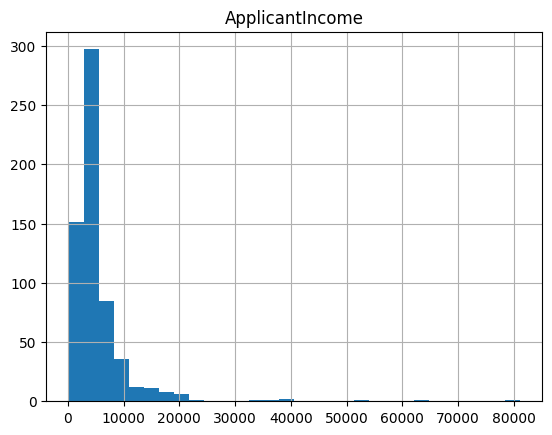

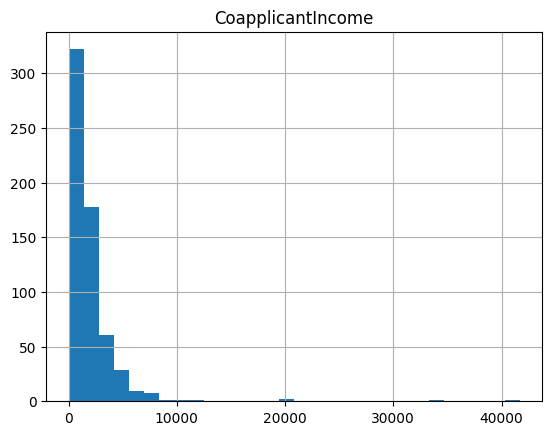

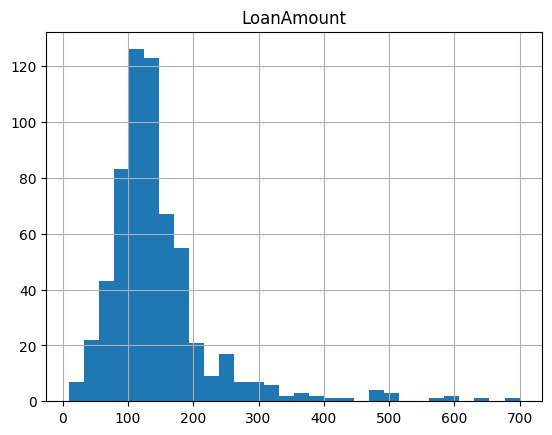

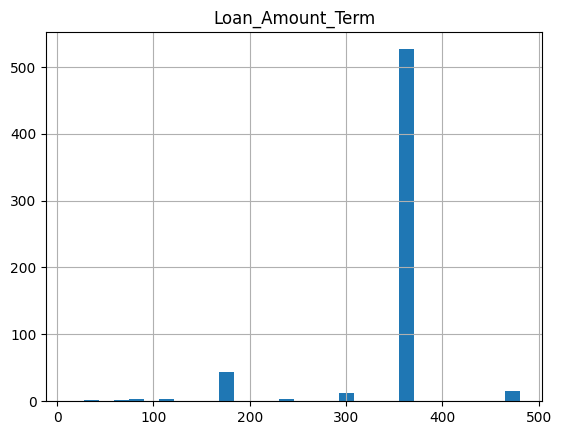

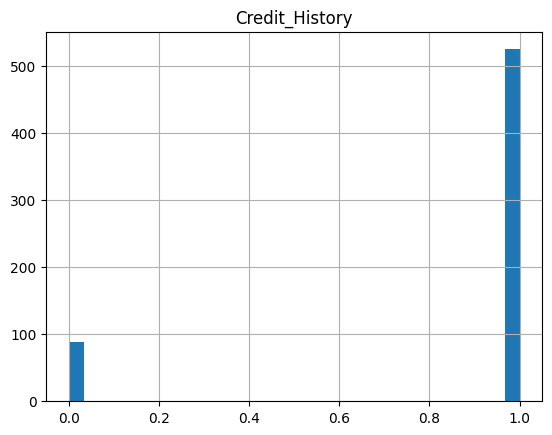

In [12]:
for col in num_col:
    df[col].hist(bins=30)
    plt.title(col)
    plt.show()

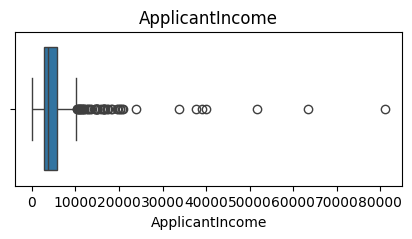

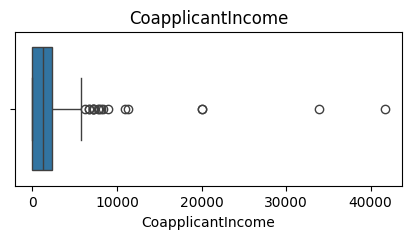

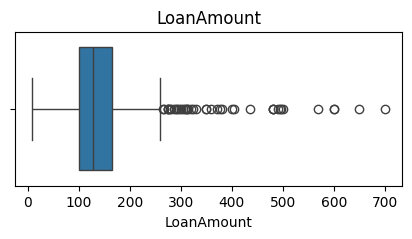

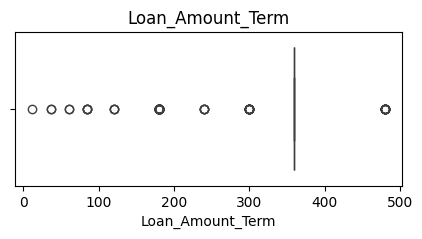

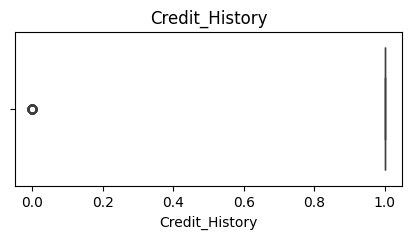

In [13]:
for col in num_col:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

<Axes: xlabel='Property_Area', ylabel='count'>

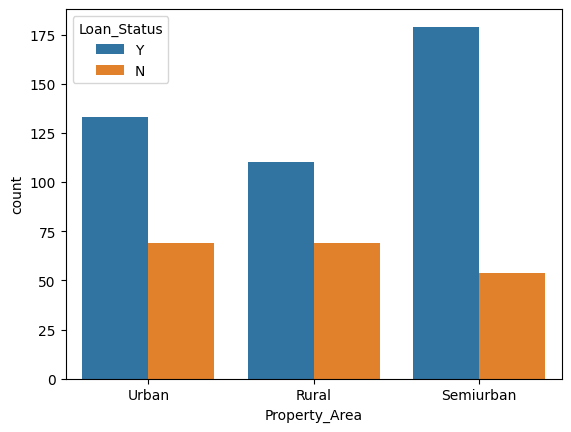

In [14]:
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)

<Axes: xlabel='Education', ylabel='count'>

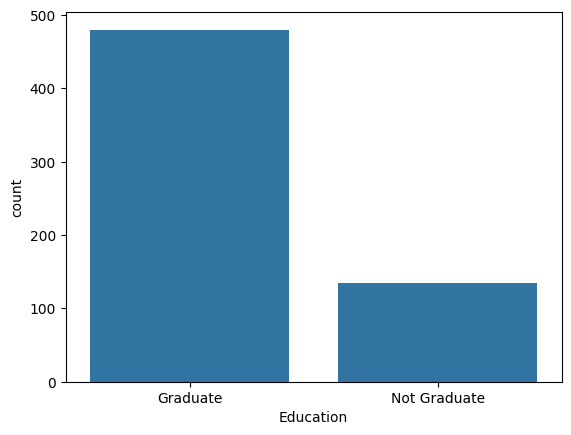

In [15]:
sns.countplot(x='Education', data=df)

<Axes: xlabel='Credit_History', ylabel='count'>

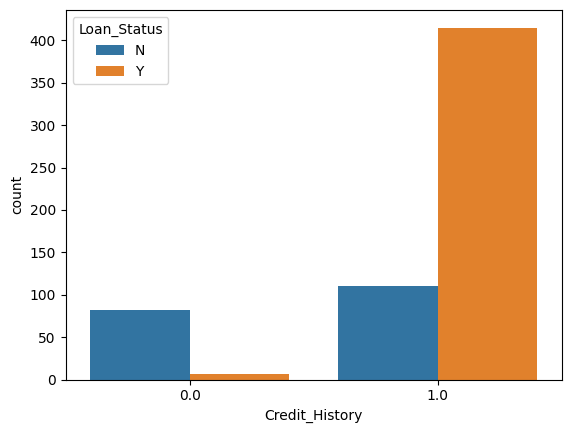

In [16]:
sns.countplot(data=df,x='Credit_History',hue='Loan_Status')

<Axes: xlabel='Education', ylabel='count'>

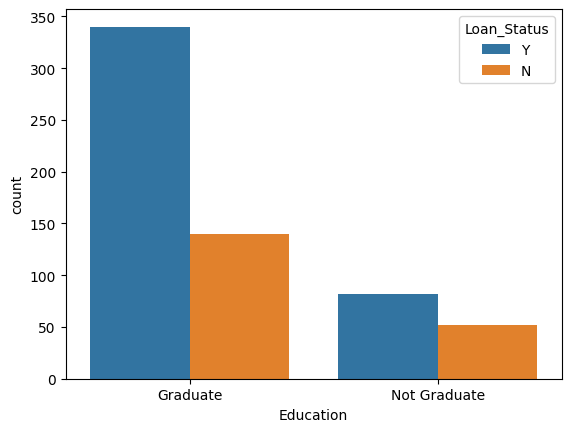

In [17]:
sns.countplot(data=df,x='Education',hue='Loan_Status')

<Axes: xlabel='Loan_Status', ylabel='ApplicantIncome'>

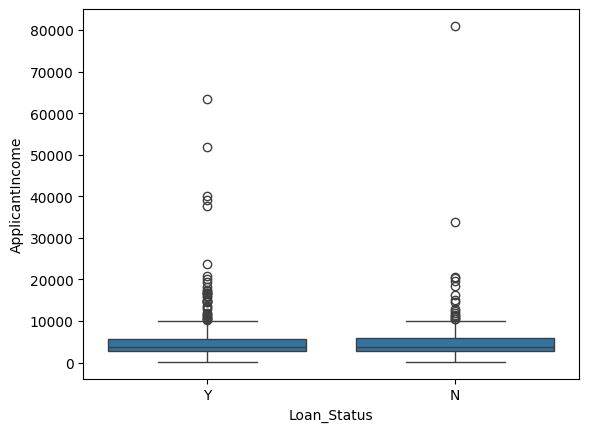

In [18]:
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)

In [19]:
df['TotalIncome']=df['CoapplicantIncome']+df['ApplicantIncome']
df.drop(columns=['CoapplicantIncome','ApplicantIncome'],axis=1)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,LP001002,Male,No,0.0,Graduate,No,128.0,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1.0,Graduate,No,128.0,360.0,1.0,Rural,N,6091.0
2,LP001005,Male,Yes,0.0,Graduate,Yes,66.0,360.0,1.0,Urban,Y,3000.0
3,LP001006,Male,Yes,0.0,Not Graduate,No,120.0,360.0,1.0,Urban,Y,4941.0
4,LP001008,Male,No,0.0,Graduate,No,141.0,360.0,1.0,Urban,Y,6000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0.0,Graduate,No,71.0,360.0,1.0,Rural,Y,2900.0
610,LP002979,Male,Yes,3.0,Graduate,No,40.0,180.0,1.0,Rural,Y,4106.0
611,LP002983,Male,Yes,1.0,Graduate,No,253.0,360.0,1.0,Urban,Y,8312.0
612,LP002984,Male,Yes,2.0,Graduate,No,187.0,360.0,1.0,Urban,Y,7583.0


<Axes: xlabel='Loan_Status', ylabel='TotalIncome'>

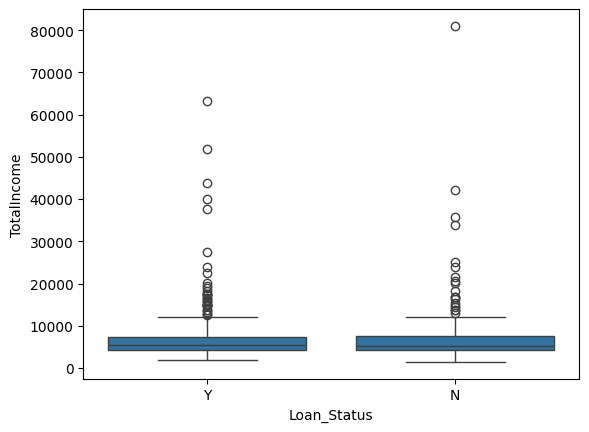

In [20]:
sns.boxplot(x='Loan_Status', y='TotalIncome', data=df)

In [21]:
pd.crosstab(df['Credit_History'], df['Loan_Status'], normalize='index')*100


Loan_Status,N,Y
Credit_History,,
0.0,92.134831,7.865169
1.0,20.952381,79.047619


In [22]:
pd.crosstab(df['Education'], df['Loan_Status'], normalize='index')*100

Loan_Status,N,Y
Education,,
Graduate,29.166667,70.833333
Not Graduate,38.805970,61.194030


In [23]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0


<Axes: xlabel='Loan_Status', ylabel='LoanIncomeRatio'>

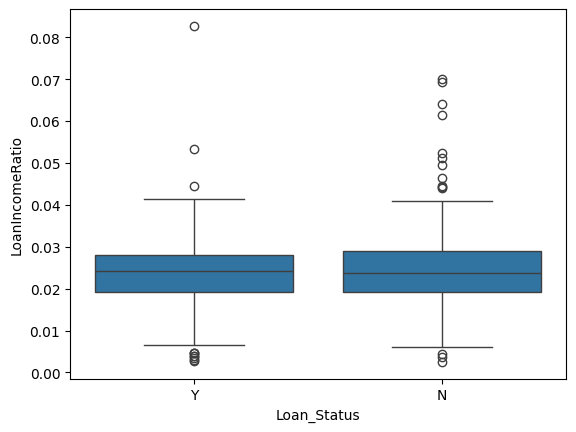

In [24]:
df['LoanIncomeRatio'] = df['LoanAmount'] / df['TotalIncome']


sns.boxplot(x='Loan_Status', y='LoanIncomeRatio', data=df)

In [25]:
import numpy as np

df['ApplicantIncome_Log'] = np.log1p(df['ApplicantIncome'])

df['CoapplicantIncome_Log'] = np.log1p(df['CoapplicantIncome'])

df['TotalIncome_Log'] = np.log1p(df['TotalIncome'])

df['LoanAmount_Log'] = np.log1p(df['LoanAmount'])


In [26]:
# loan to income ration
df['LoanIncomeRatio'] = df['LoanAmount'] / df['TotalIncome']
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanIncomeRatio,ApplicantIncome_Log,CoapplicantIncome_Log,TotalIncome_Log,LoanAmount_Log
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0,0.021884,8.674197,0.000000,8.674197,4.859812
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,0.021015,8.430327,7.319202,8.714732,4.859812
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,0.022000,8.006701,0.000000,8.006701,4.204693
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,0.024287,7.857094,7.765993,8.505525,4.795791
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,0.023500,8.699681,0.000000,8.699681,4.955827


<Axes: xlabel='TotalIncome_Log', ylabel='Count'>

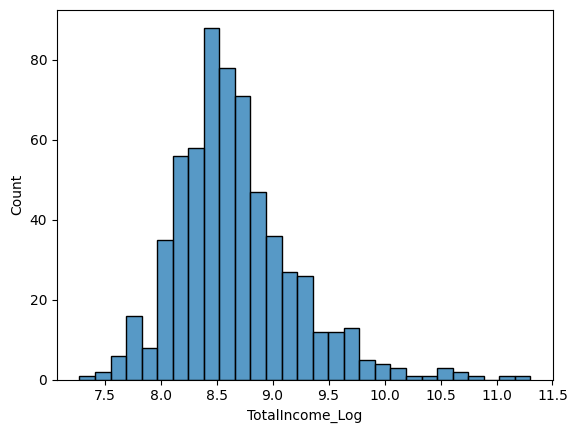

In [27]:
sns.histplot(df['TotalIncome_Log'])

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Loan_ID                614 non-null    object 
 1   Gender                 614 non-null    object 
 2   Married                614 non-null    object 
 3   Dependents             614 non-null    float64
 4   Education              614 non-null    object 
 5   Self_Employed          614 non-null    object 
 6   ApplicantIncome        614 non-null    int64  
 7   CoapplicantIncome      614 non-null    float64
 8   LoanAmount             614 non-null    float64
 9   Loan_Amount_Term       614 non-null    float64
 10  Credit_History         614 non-null    float64
 11  Property_Area          614 non-null    object 
 12  Loan_Status            614 non-null    object 
 13  TotalIncome            614 non-null    float64
 14  LoanIncomeRatio        614 non-null    float64
 15  Applic

In [29]:
df1=df.copy()
df1.drop(columns=['TotalIncome','Loan_ID','LoanAmount','ApplicantIncome','CoapplicantIncome','ApplicantIncome_Log','CoapplicantIncome_Log'],inplace=True,axis=1)

## Key Findings:

Missing values were handled 

Credit History strongly impacts loan approval.

Applicants with higher total income show better approval rates.

Loan amount and applicant income were right-skewed.

Semiurban people showed relatively higher approval probability.



## Feature Engineering Summary

dropped applicantincome and coapplicantincome(also there logs)

TotalIncome feature

Log transformations

Repayment-capacity feature

In [30]:
# saving dataset
df1.to_csv("C:/Users/Adhrav/Desktop/Env/notebooks/data/loan_processed.csv", index=False)

In that case recreate it:

cd C:\Users\Adhrav\Desktop
python -m venv Env

Then activate:

.\Env\Scripts\Activate.ps1

If PowerShell blocks execution, run:

Set-ExecutionPolicy -Scope CurrentUser RemoteSigned

Then:

Y

and retry activation.

After successful activation you should see:

(Env) PS C:\Users\Adhrav\Desktop>